# **Book Recommendation System**

## **Name: Parth Khera**

## **Class: CSE-A**

## **Roll No.: 169-CSE-A-23**

## **Enrollment No.: 35820802723**

In [ ]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

[DataSet Link](https://www.kaggle.com/datasets/abdallahwagih/books-dataset)


In [ ]:
# Dataset Load
df = pd.read_csv('/content/drive/MyDrive/DataSets Colab File/data.csv')

## **Data Wrangling**

In [ ]:
df.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   object 
 2   title           6810 non-null   object 
 3   subtitle        2381 non-null   object 
 4   authors         6738 non-null   object 
 5   categories      6711 non-null   object 
 6   thumbnail       6481 non-null   object 
 7   description     6548 non-null   object 
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 638.6+ KB


In [ ]:
df.shape

(6810, 12)

### Missing Values

In [ ]:
df.isnull().sum()

,0
isbn13,0
isbn10,0
title,0
subtitle,4429
authors,72
categories,99
thumbnail,329
description,262
published_year,6
average_rating,43


<Axes: >

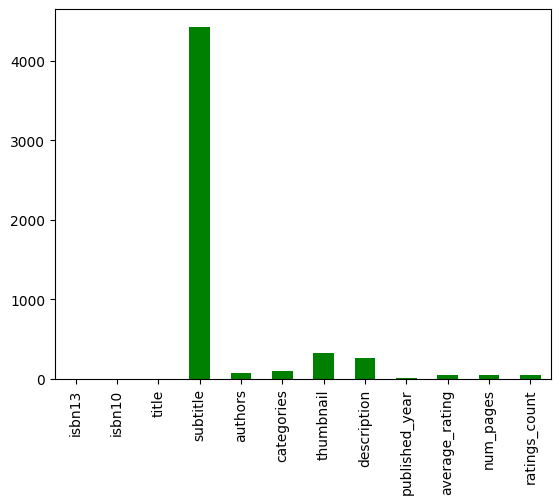

In [ ]:
df.isnull().sum().plot(kind='bar', color='green')

In [ ]:
df.fillna(" ",inplace=True)

/tmp/ipykernel_2526/2801255387.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value ' ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna(" ",inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   isbn13          6810 non-null   int64 
 1   isbn10          6810 non-null   object
 2   title           6810 non-null   object
 3   subtitle        6810 non-null   object
 4   authors         6810 non-null   object
 5   categories      6810 non-null   object
 6   thumbnail       6810 non-null   object
 7   description     6810 non-null   object
 8   published_year  6810 non-null   object
 9   average_rating  6810 non-null   object
 10  num_pages       6810 non-null   object
 11  ratings_count   6810 non-null   object
dtypes: int64(1), object(11)
memory usage: 638.6+ KB


In [ ]:
df.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


In [ ]:
df.columns

Index(['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories',
       'thumbnail', 'description', 'published_year', 'average_rating',
       'num_pages', 'ratings_count'],
      dtype='object')

### Columns Merging

In [ ]:
df['content'] = (df['title'] + ' ' + df['subtitle'] + ' ' + df['authors'] + ' ' + df['categories'] + ' ' + df['description'])

In [ ]:
df.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,content
0,9780002005883,0002005883,Gilead,,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,Gilead Marilynne Robinson Fiction A NOVEL TH...
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,Spider's Web A Novel Charles Osborne;Agatha Ch...
2,9780006163831,0006163831,The One Tree,,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,The One Tree Stephen R. Donaldson American f...
3,9780006178736,0006178731,Rage of angels,,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,Rage of angels Sidney Sheldon Fiction A memo...
4,9780006280897,0006280897,The Four Loves,,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,The Four Loves Clive Staples Lewis Christian...


In [ ]:
df['content'] = df['content'].str.lower()

In [ ]:
df['content'] = df['content'].str.replace(r'\s+', ' ')

### TF-IDF Vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['content'])

In [ ]:
print(tfidf_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 253725 stored elements and shape (6810, 33617)>
  Coords	Values
  (0, 12759)	0.4797195006217876
  (0, 18667)	0.1038234315090146
  (0, 25656)	0.0760594144904797
  (0, 11476)	0.01945106023916253
  (0, 20957)	0.035958063872685644
  (0, 24463)	0.09578852988404862
  (0, 7375)	0.14130982320458188
  (0, 9589)	0.08552772621243261
  (0, 1848)	0.09921420112573477
  (0, 7962)	0.07005647022961045
  (0, 2408)	0.09133466974107768
  (0, 14969)	0.07823128473174466
  (0, 28735)	0.11073482556776276
  (0, 24956)	0.06067721808569892
  (0, 17819)	0.046825898241313585
  (0, 16266)	0.17392125512132264
  (0, 1548)	0.3736290303883587
  (0, 23263)	0.17916464335489454
  (0, 27968)	0.2168990790544377
  (0, 13136)	0.09133466974107768
  (0, 18856)	0.09921420112573477
  (0, 22105)	0.09594390012435752
  (0, 23264)	0.1038234315090146
  (0, 336)	0.09133466974107768
  (0, 15859)	0.09594390012435752
  :	:
  (6808, 22597)	0.10407921714954914
  (6808, 15646)	0.1

### Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
similarity = cosine_similarity(tfidf_matrix)

In [ ]:
print(similarity)

[[1.         0.00291561 0.00119768 ... 0.         0.00519035 0.        ]
 [0.00291561 1.         0.01220505 ... 0.         0.00315068 0.02394566]
 [0.00119768 0.01220505 1.         ... 0.         0.00668108 0.        ]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.00519035 0.00315068 0.00668108 ... 0.         1.         0.        ]
 [0.         0.02394566 0.         ... 0.         0.         1.        ]]


In [ ]:
similarity.shape

(6810, 6810)

In [ ]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

from difflib import get_close_matches

book_titles = df['title'].tolist()

### Recommendation System Function

In [ ]:
from difflib import get_close_matches

def recommend(book_name, n=10):
    book_name = book_name.lower().strip()

    title_matches = df[df['title'].str.lower().str.contains(book_name, na=False)]

    if len(title_matches) > 0:
        idx = title_matches.index[0]
    else:
        closest = get_close_matches(book_name,df['title'].tolist(),n=1,cutoff=0.6)

        if len(closest) == 0:
            return {
                "status": "Book Not Found",
                "books": None
            }
        print(f"\nBook not found.\nShowing results for '{closest[0]}'")

        idx = df[df['title'] == closest[0]].index[0]

    distances = list(enumerate(similarity[idx]))

    distances = sorted(distances,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    for i in distances[1:n+1]:
        book = df.iloc[i[0]]
        recommendations.append(
            {
                "title": book['title'],
                "author": book['authors'],
                "category": book['categories'],
                "description": book['description'],
                "rating": book['average_rating'],
                "similarity_score": round(float(i[1]),3)
            }
        )

    return {
        "status": "Recommended Books",
        "books": recommendations
    }

### Output

In [ ]:
name = input("Enter Book Name: ")
result = recommend(name)
print("\nStatus:", result["status"])
print("="*70)

if result["books"] is not None:
    for i, book in enumerate(result["books"],1):
        print("\nBook", i)
        print("-"*50)
        print("Title       :", book["title"])
        print("Author      :", book["author"])
        print("Category    :", book["category"])
        print("Description :", book["description"])
        print("Rating      :", book["rating"])
        print("Similarity  :", book["similarity_score"])
else:
    print("No matching book found.")

Enter Book Name: ramayan

Book not found.
Showing results for 'Trauma'

Status: Recommended Books

Book 1
--------------------------------------------------
Title       : The Body Remembers: The Psychophysiology of Trauma and Trauma Treatment
Author      : Babette Rothschild
Category    : Health & Fitness
Description : Relates the impact of trauma on the body to the phenomenon of somatic memory. The book illuminates the value of understanding the psychophysiology of trauma for both therapists and their traumatised clients. It progresses from relevant theory to applicable practice.
Rating      : 4.27
Similarity  : 0.16

Book 2
--------------------------------------------------
Title       : Chilly Scenes of Winter
Author      : Ann Beattie
Category    : Fiction
Description : This is the story of a love-smitten Charles; his friend Sam, the Phi Beta Kappa and former coat salesman; and Charles' mother, who spends a lot of time in the bathtub feeling depressed.
Rating      : 3.91
Similarity